In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from blimpy import Waterfall


PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "hip70016_mid"
    / "spliced_blc02030405_2bit_guppi_57472_28848_HIP70016_0020.gpuspec.0002.h5"
)

print("File exists:", DATA_PATH.exists())
print(DATA_PATH)

File exists: True
/Users/parthshringarpure/deepseti/data/raw/hip70016_mid/spliced_blc02030405_2bit_guppi_57472_28848_HIP70016_0020.gpuspec.0002.h5


/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
wf = Waterfall(
    str(DATA_PATH),
    f_start=1490,
    f_stop=1510,
)

print("Loaded shape:", wf.data.shape)

Loaded shape: (277, 1, 6990)


In [3]:
data = wf.data.squeeze()

print("Original shape:", wf.data.shape)
print("Simplified shape:", data.shape)

Original shape: (277, 1, 6990)
Simplified shape: (277, 6990)


In [4]:
frame = data[:16, :4096]

print("Frame shape:", frame.shape)

Frame shape: (16, 4096)


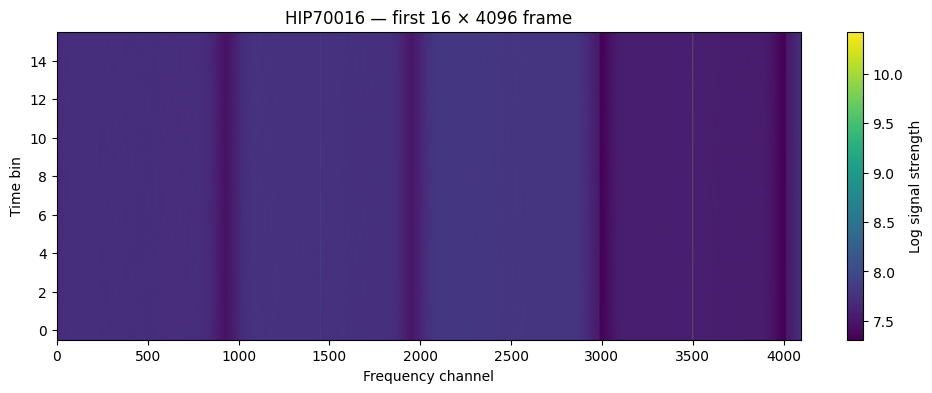

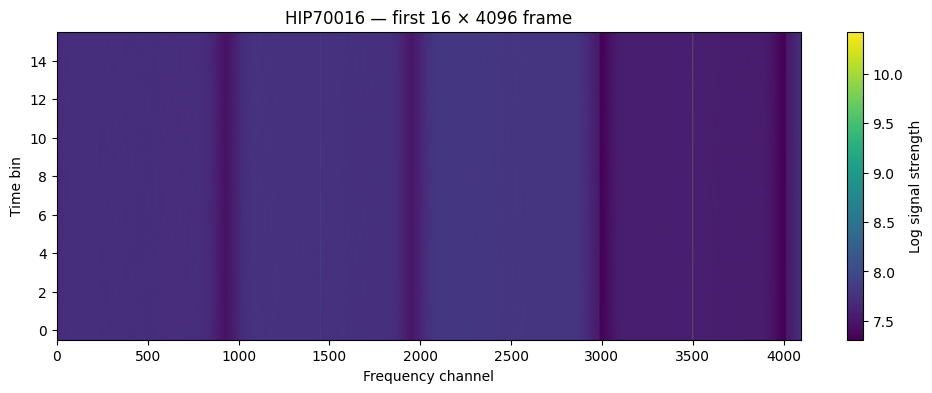

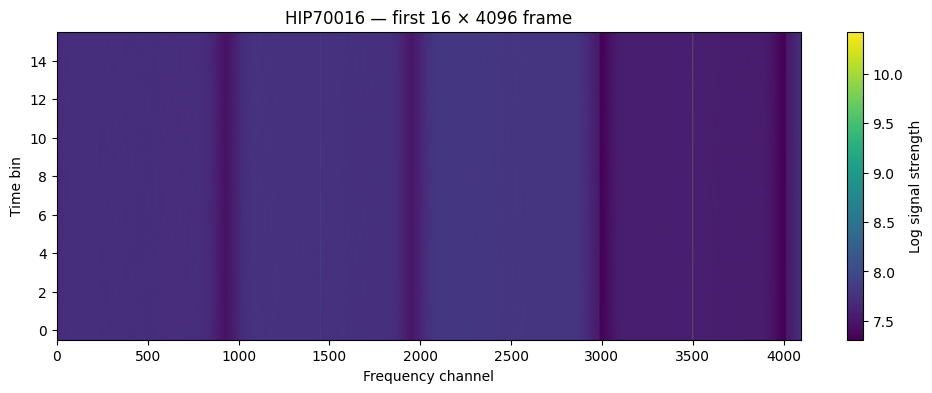

In [7]:
%matplotlib inline

frame_log = np.log10(frame)

plt.figure(figsize=(12, 4))

plt.imshow(
    frame_log,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Frequency channel")
plt.ylabel("Time bin")
plt.title("HIP70016 — first 16 × 4096 frame")

plt.colorbar(label="Log signal strength")

plt.show()

In [8]:
print("Minimum:", frame_log.min())
print("Maximum:", frame_log.max())
print("Mean:", frame_log.mean())
print("Std dev:", frame_log.std())

Minimum: 7.310099
Maximum: 10.424087
Mean: 7.6795044
Std dev: 0.116361134


In [9]:
percentiles = np.percentile(
    frame_log,
    [1, 5, 50, 95, 99, 99.9]
)

for p, value in zip([1, 5, 50, 95, 99, 99.9], percentiles):
    print(f"{p:>5}% : {value:.4f}")

    1% : 7.3501
    5% : 7.4982
   50% : 7.7164
   95% : 7.8019
   99% : 7.8098
 99.9% : 7.8176


In [10]:
median = np.median(frame_log)

mad = np.median(
    np.abs(frame_log - median)
)

print("Median:", median)
print("MAD:", mad)

Median: 7.7164125
MAD: 0.072178364


In [11]:
normalized_frame = (frame_log - median) / mad

print("Normalized median:", np.median(normalized_frame))
print("Normalized MAD:", np.median(np.abs(normalized_frame)))
print("Minimum:", normalized_frame.min())
print("Maximum:", normalized_frame.max())

Normalized median: -3.303186e-06
Normalized MAD: 1.0
Minimum: -5.629297
Maximum: 37.513653


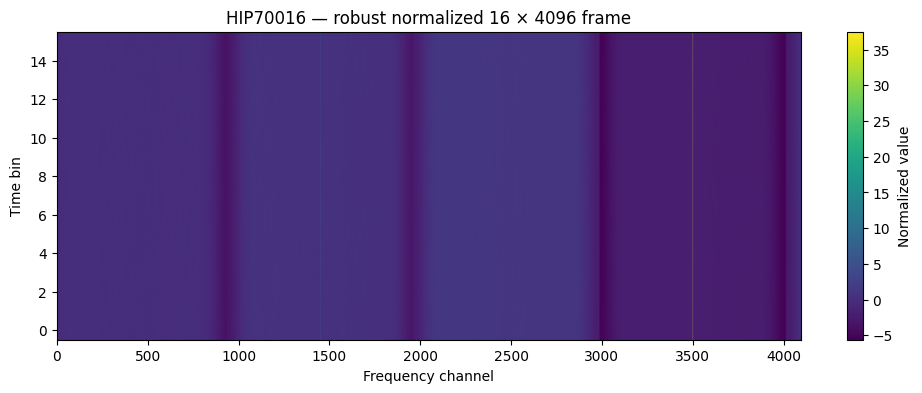

In [12]:
plt.figure(figsize=(12, 4))

plt.imshow(
    normalized_frame,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Frequency channel")
plt.ylabel("Time bin")
plt.title("HIP70016 — robust normalized 16 × 4096 frame")

plt.colorbar(label="Normalized value")

plt.show()

In [13]:
percentiles = np.percentile(
    normalized_frame,
    [1, 50, 95, 99, 99.9, 99.99]
)

for p, value in zip([1, 50, 95, 99, 99.9, 99.99], percentiles):
    print(f"{p:>6}% : {value:.3f}")

     1% : -5.075
    50% : -0.000
    95% : 1.184
    99% : 1.294
  99.9% : 1.402
 99.99% : 37.202


In [14]:
total_pixels = normalized_frame.size

for threshold in [2, 5, 10, 20]:
    count = np.sum(normalized_frame > threshold)
    percentage = 100 * count / total_pixels

    print(
        f"> {threshold:2}: {count:4} pixels "
        f"({percentage:.4f}%)"
    )

>  2:   32 pixels (0.0488%)
>  5:   32 pixels (0.0488%)
> 10:   32 pixels (0.0488%)
> 20:   16 pixels (0.0244%)


In [15]:
rows, cols = np.where(normalized_frame > 10)

print("Rows:", rows)
print("Columns:", cols)
print("Unique columns:", np.unique(cols))

Rows: [ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  8  9  9 10 10 11 11
 12 12 13 13 14 14 15 15]
Columns: [1447 3495 1447 3495 1447 3495 1447 3495 1447 3495 1447 3495 1447 3495
 1447 3495 1447 3495 1447 3495 1447 3495 1447 3495 1447 3495 1447 3495
 1447 3495 1447 3495]
Unique columns: [1447 3495]


In [16]:
frames = []

time_window = 16
freq_window = 4096

for start_time in range(0, data.shape[0] - time_window + 1, time_window):
    frame = data[
        start_time:start_time + time_window,
        :freq_window,
    ]

    frames.append(frame)

print("Number of frames:", len(frames))
print("Shape of first frame:", frames[0].shape)
print("Shape of last frame:", frames[-1].shape)

Number of frames: 17
Shape of first frame: (16, 4096)
Shape of last frame: (16, 4096)


In [17]:
frames = []

time_window = 16
freq_window = 4096

for start_time in range(0, data.shape[0] - time_window + 1, time_window):
    for start_freq in range(0, data.shape[1] - freq_window + 1, freq_window):

        frame = data[
            start_time:start_time + time_window,
            start_freq:start_freq + freq_window,
        ]

        frames.append(frame)

print("Number of frames:", len(frames))
print("Shape of first frame:", frames[0].shape)
print("Shape of last frame:", frames[-1].shape)

Number of frames: 17
Shape of first frame: (16, 4096)
Shape of last frame: (16, 4096)


In [18]:
wf_wide = Waterfall(
    str(DATA_PATH),
    f_start=1450,
    f_stop=1550,
)

wide_data = wf_wide.data.squeeze()

print("Wide data shape:", wide_data.shape)

Wide data shape: (277, 34952)


In [19]:
frames = []

time_window = 16
freq_window = 4096

for start_time in range(0, wide_data.shape[0] - time_window + 1, time_window):
    for start_freq in range(0, wide_data.shape[1] - freq_window + 1, freq_window):

        frame = wide_data[
            start_time:start_time + time_window,
            start_freq:start_freq + freq_window,
        ]

        frames.append(frame)

print("Number of frames:", len(frames))
print("First frame shape:", frames[0].shape)
print("Last frame shape:", frames[-1].shape)

Number of frames: 136
First frame shape: (16, 4096)
Last frame shape: (16, 4096)


In [20]:
frames_array = np.stack(frames)

print("Dataset shape:", frames_array.shape)

Dataset shape: (136, 16, 4096)


In [21]:
frame_medians = []
frame_mads = []

for frame in frames_array:
    log_frame = np.log10(frame)

    median = np.median(log_frame)
    mad = np.median(np.abs(log_frame - median))

    frame_medians.append(median)
    frame_mads.append(mad)

frame_medians = np.array(frame_medians)
frame_mads = np.array(frame_mads)

print("Median range:", frame_medians.min(), "to", frame_medians.max())
print("MAD range:", frame_mads.min(), "to", frame_mads.max())
print("Median of medians:", np.median(frame_medians))
print("Median of MADs:", np.median(frame_mads))

Median range: 7.5519934 to 7.828061
MAD range: 0.009384632 to 0.08138895
Median of medians: 7.723082
Median of MADs: 0.016977549


In [22]:
normalized_frames = []

for frame in frames_array:
    log_frame = np.log10(frame)

    median = np.median(log_frame)
    mad = np.median(np.abs(log_frame - median))

    normalized = (log_frame - median) / mad

    normalized_frames.append(normalized)

normalized_frames = np.stack(normalized_frames)

print("Normalized dataset shape:", normalized_frames.shape)
print("Overall median:", np.median(normalized_frames))

Normalized dataset shape: (136, 16, 4096)
Overall median: 0.0


In [23]:
print("Shape:", normalized_frames.shape)
print("All values finite:", np.isfinite(normalized_frames).all())
print("Minimum:", normalized_frames.min())
print("Maximum:", normalized_frames.max())

Shape: (136, 16, 4096)
All values finite: True
Minimum: -42.71699
Maximum: 108.36576


In [24]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "hip70016_mid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(
    OUTPUT_DIR / "frames.npy",
    normalized_frames.astype(np.float32),
)

print("Saved to:", OUTPUT_DIR / "frames.npy")

Saved to: /Users/parthshringarpure/deepseti/data/processed/hip70016_mid/frames.npy


In [25]:
import json

metadata = {
    "source_name": str(wf_wide.header["source_name"]),
    "observation_file": DATA_PATH.name,
    "frequency_range_mhz": [1450, 1550],
    "original_selected_shape": list(wide_data.shape),
    "num_frames": int(normalized_frames.shape[0]),
    "frame_shape": [16, 4096],
    "time_window": 16,
    "frequency_window": 4096,
    "normalization": "log10 + per-frame median/MAD",
    "resolution": "mid",
    "purpose": "preprocessing development only",
}

METADATA_PATH = OUTPUT_DIR / "metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

{
  "source_name": "HIP70016",
  "observation_file": "spliced_blc02030405_2bit_guppi_57472_28848_HIP70016_0020.gpuspec.0002.h5",
  "frequency_range_mhz": [
    1450,
    1550
  ],
  "original_selected_shape": [
    277,
    34952
  ],
  "num_frames": 136,
  "frame_shape": [
    16,
    4096
  ],
  "time_window": 16,
  "frequency_window": 4096,
  "normalization": "log10 + per-frame median/MAD",
  "resolution": "mid",
  "purpose": "preprocessing development only"
}


In [26]:
import csv

frame_metadata = []
frame_id = 0

for start_time in range(0, wide_data.shape[0] - time_window + 1, time_window):
    for start_freq in range(0, wide_data.shape[1] - freq_window + 1, freq_window):

        frame_metadata.append({
            "frame_id": frame_id,
            "source_name": "HIP70016",
            "observation_file": DATA_PATH.name,
            "time_start_idx": start_time,
            "time_stop_idx": start_time + time_window,
            "freq_start_idx": start_freq,
            "freq_stop_idx": start_freq + freq_window,
        })

        frame_id += 1

FRAME_METADATA_PATH = OUTPUT_DIR / "frame_metadata.csv"

with open(FRAME_METADATA_PATH, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=frame_metadata[0].keys()
    )

    writer.writeheader()
    writer.writerows(frame_metadata)

print("Metadata rows:", len(frame_metadata))
print("Saved to:", FRAME_METADATA_PATH)
print("\nFirst frame:")
print(frame_metadata[0])

Metadata rows: 136
Saved to: /Users/parthshringarpure/deepseti/data/processed/hip70016_mid/frame_metadata.csv

First frame:
{'frame_id': 0, 'source_name': 'HIP70016', 'observation_file': 'spliced_blc02030405_2bit_guppi_57472_28848_HIP70016_0020.gpuspec.0002.h5', 'time_start_idx': 0, 'time_stop_idx': 16, 'freq_start_idx': 0, 'freq_stop_idx': 4096}


In [27]:
from deepseti.preprocessing.frames import robust_normalize_frame

test_normalized = robust_normalize_frame(frames_array[0])

print("Shape:", test_normalized.shape)
print("dtype:", test_normalized.dtype)
print(
    "Matches notebook result:",
    np.allclose(test_normalized, normalized_frames[0])
)

Shape: (16, 4096)
dtype: float32
Matches notebook result: True


In [28]:
import importlib
import deepseti.preprocessing.frames as frame_utils

importlib.reload(frame_utils)

test_frames = frame_utils.extract_frames(wide_data)

print("Extracted shape:", test_frames.shape)

print(
    "Matches notebook frames:",
    np.array_equal(test_frames, frames_array),
)

Extracted shape: (136, 16, 4096)
Matches notebook frames: True


In [29]:
importlib.reload(frame_utils)

test_normalized_frames = frame_utils.normalize_frames(test_frames)

print("Shape:", test_normalized_frames.shape)
print("dtype:", test_normalized_frames.dtype)

print(
    "Matches notebook normalization:",
    np.allclose(
        test_normalized_frames,
        normalized_frames,
    ),
)

Shape: (136, 16, 4096)
dtype: float32
Matches notebook normalization: True


In [30]:
importlib.reload(frame_utils)

processed = frame_utils.preprocess_spectrogram(wide_data)

print("Processed shape:", processed.shape)

print(
    "Matches notebook result:",
    np.allclose(processed, normalized_frames),
)

Processed shape: (136, 16, 4096)
Matches notebook result: True
